<center>

# Forest Cover Type Exploratory Analysis

    Full UCI Covertype dataset

</center>

## Introduction

The Forest Covertype dataset asks us to predict the dominant tree cover type for 30m x 30m forest cells from cartographic variables. The features describe elevation, aspect, slope, hydrology distance, road distance, hillshade, wildfire ignition distance, wilderness area, and soil type. This notebook follows the report-style exploratory flow of the original project notebook while using the full UCI dataset and clearer plot labeling.

The seven cover types are:

1. Spruce/Fir
2. Lodgepole Pine
3. Ponderosa Pine
4. Cottonwood/Willow
5. Aspen
6. Douglas-fir
7. Krummholz

### Data Fields

Name | Unit | Description
---|---:|---
Elevation | meters | Elevation of the forest cell
Aspect | degrees azimuth | Direction of the terrain slope, measured clockwise from north
Slope | degrees | Inclination of the terrain
Horizontal_Distance_To_Hydrology | meters | Horizontal distance to nearest surface water
Vertical_Distance_To_Hydrology | meters | Vertical offset from nearest surface water
Horizontal_Distance_To_Roadways | meters | Horizontal distance to nearest roadway
Hillshade_9am | 0-255 index | Hillshade at 9am on summer solstice
Hillshade_Noon | 0-255 index | Hillshade at noon on summer solstice
Hillshade_3pm | 0-255 index | Hillshade at 3pm on summer solstice
Horizontal_Distance_To_Fire_Points | meters | Horizontal distance to nearest wildfire ignition point
Wilderness_Area | one-hot binary | Wilderness area designation
Soil_Type | one-hot binary | Soil type designation
Cover_Type | class label | Dominant forest cover type

## Fetch the Dataset

In [19]:
%matplotlib inline

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from covertype_resource.data import load_covertype
from covertype_resource.metrics import LogEuclideanTransformer

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 120)

In [20]:
dataset = load_covertype()
X = dataset.X
y = dataset.y
df = X.assign(Cover_Type=y)

cover_names = {
    1: "Spruce/Fir",
    2: "Lodgepole Pine",
    3: "Ponderosa Pine",
    4: "Cottonwood/Willow",
    5: "Aspen",
    6: "Douglas-fir",
    7: "Krummholz",
}

feature_labels = {
    "Elevation": "Elevation (m)",
    "Aspect": "Aspect (degrees azimuth)",
    "Slope": "Slope (degrees)",
    "Horizontal_Distance_To_Hydrology": "Horizontal distance to hydrology (m)",
    "Vertical_Distance_To_Hydrology": "Vertical distance to hydrology (m)",
    "Horizontal_Distance_To_Roadways": "Horizontal distance to roadways (m)",
    "Hillshade_9am": "Hillshade at 9am (0-255)",
    "Hillshade_Noon": "Hillshade at noon (0-255)",
    "Hillshade_3pm": "Hillshade at 3pm (0-255)",
    "Horizontal_Distance_To_Fire_Points": "Horizontal distance to fire points (m)",
}

short_feature_labels = {
    "Elevation": "Elevation",
    "Aspect": "Aspect",
    "Slope": "Slope",
    "Horizontal_Distance_To_Hydrology": "Hydrology H",
    "Vertical_Distance_To_Hydrology": "Hydrology V",
    "Horizontal_Distance_To_Roadways": "Roadways H",
    "Hillshade_9am": "Hillshade 9am",
    "Hillshade_Noon": "Hillshade noon",
    "Hillshade_3pm": "Hillshade 3pm",
    "Horizontal_Distance_To_Fire_Points": "Fire points H",
}

def cover_label(value):
    return f"{int(value)} - {cover_names[int(value)]}"

cover_order = [cover_label(i) for i in sorted(cover_names)]
palette = dict(zip(cover_order, sns.color_palette("tab10", n_colors=7)))

df_plot = df.assign(Cover_Label=df["Cover_Type"].map(cover_label))
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area1,Soil_Type1,Soil_Type2,Soil_Type3,Soil_Type4,Soil_Type5,Soil_Type6,Soil_Type7,Soil_Type8,Soil_Type9,Soil_Type10,Soil_Type11,Soil_Type12,Soil_Type13,Soil_Type14,Soil_Type15,Soil_Type16,Soil_Type17,Soil_Type18,Soil_Type19,Soil_Type20,Soil_Type21,Soil_Type22,Soil_Type23,Soil_Type24,Soil_Type25,Soil_Type26,Soil_Type27,Soil_Type28,Soil_Type29,Soil_Type30,Soil_Type31,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5


#### Interpretation

The data loads as a regular tabular dataset with numeric columns. The target is stored as integer labels from 1 to 7, and the notebook maps those labels to readable cover names so the plots are easier to understand.

## Initial Data Analysis

#### Determine Shape, Size, and Feature Groups

In [21]:
wilderness_cols = [c for c in X.columns if c.startswith("Wilderness_Area")]
soil_cols = [c for c in X.columns if c.startswith("Soil_Type")]
binary_cols = wilderness_cols + soil_cols
continuous_cols = [c for c in X.columns if c not in binary_cols]

shape_summary = pd.DataFrame(
    {
        "rows": [df.shape[0]],
        "predictive_features": [X.shape[1]],
        "continuous_features": [len(continuous_cols)],
        "wilderness_indicators": [len(wilderness_cols)],
        "soil_indicators": [len(soil_cols)],
        "target_classes": [y.nunique()],
        "memory_mb": [round(df.memory_usage(deep=True).sum() / 1_000_000, 2)],
    }
)
shape_summary

,rows,predictive_features,continuous_features,wilderness_indicators,soil_indicators,target_classes,memory_mb
0,581012,54,10,4,40,7,255.65


#### Interpretation

This is a large dataset: 581,012 rows and 54 predictive features. The features are already split into useful groups: 10 continuous cartographic measurements, 4 wilderness-area indicators, and 40 soil-type indicators. Because the dataset is large, it makes sense to tune expensive models on a sample first and then train the selected setup on the full train split.

#### Determine Data Types, Missing Values, and Duplicates

In [22]:
data_quality = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "unique_values": df.nunique(),
        "minimum": df.min(numeric_only=True),
        "maximum": df.max(numeric_only=True),
    }
)

duplicate_rows = int(df.duplicated().sum())
constant_features = [c for c in X.columns if X[c].nunique() <= 1]
rare_binary = X[binary_cols].sum().sort_values().head(10)

display(data_quality.head(18))
pd.DataFrame(
    {
        "check": ["duplicate rows", "constant predictive features", "features with missing values"],
        "value": [duplicate_rows, len(constant_features), int((X.isna().sum() > 0).sum())],
    }
)

,dtype,missing,unique_values,minimum,maximum
Elevation,int64,0,1978,1859,3858
Aspect,int64,0,361,0,360
Slope,int64,0,67,0,66
Horizontal_Distance_To_Hydrology,int64,0,551,0,1397
Vertical_Distance_To_Hydrology,int64,0,700,-173,601
Horizontal_Distance_To_Roadways,int64,0,5785,0,7117
Hillshade_9am,int64,0,207,0,254
Hillshade_Noon,int64,0,185,0,254
Hillshade_3pm,int64,0,255,0,254
Horizontal_Distance_To_Fire_Points,int64,0,5827,0,7173


,check,value
0,duplicate rows,0
1,constant predictive features,0
2,features with missing values,0


#### Interpretation

The table is clean: there are no missing values, no duplicate rows, and no constant predictive features. That means we do not need imputation or duplicate removal before modeling. The rare binary features still need attention, because a feature can be valid even when it appears in only a small number of rows.

#### One-Hot Encoding Sanity Checks

In [23]:
one_hot_checks = pd.DataFrame(
    {
        "group": ["Wilderness_Area", "Soil_Type"],
        "columns": [len(wilderness_cols), len(soil_cols)],
        "rows_with_exactly_one_active": [
            int((X[wilderness_cols].sum(axis=1) == 1).sum()),
            int((X[soil_cols].sum(axis=1) == 1).sum()),
        ],
        "rows_with_zero_active": [
            int((X[wilderness_cols].sum(axis=1) == 0).sum()),
            int((X[soil_cols].sum(axis=1) == 0).sum()),
        ],
        "rows_with_multiple_active": [
            int((X[wilderness_cols].sum(axis=1) > 1).sum()),
            int((X[soil_cols].sum(axis=1) > 1).sum()),
        ],
    }
)
one_hot_checks

,group,columns,rows_with_exactly_one_active,rows_with_zero_active,rows_with_multiple_active
0,Wilderness_Area,4,581012,0,0
1,Soil_Type,40,581012,0,0


#### Interpretation

The wilderness and soil variables are already one-hot encoded correctly. Every row has exactly one active wilderness area and exactly one active soil type. We should not one-hot encode these columns again, and we should treat them as discrete indicators in feature relevance checks.

## Holdout-Aware Analysis Split

The modeling notebook uses an exact 20 percent holdout. For exploratory summaries below, we also create a stratified train/test split so target-dependent insights can be read with the same split convention.

In [24]:
X_train_eda, X_test_eda, y_train_eda, y_test_eda = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

split_balance = pd.concat(
    [
        y_train_eda.value_counts(normalize=True).sort_index().rename("train_percent"),
        y_test_eda.value_counts(normalize=True).sort_index().rename("test_percent"),
    ],
    axis=1,
).mul(100).round(2)
split_balance.index = [cover_label(i) for i in split_balance.index]
split_balance

,train_percent,test_percent
1 - Spruce/Fir,36.46,36.46
2 - Lodgepole Pine,48.76,48.76
3 - Ponderosa Pine,6.15,6.15
4 - Cottonwood/Willow,0.47,0.47
5 - Aspen,1.63,1.63
6 - Douglas-fir,2.99,2.99
7 - Krummholz,3.53,3.53


#### Interpretation

The stratified 80/20 split keeps the same class proportions in train and test. This is important because the target is imbalanced. The rare classes stay rare even after splitting, so metrics such as Kappa, recall, and per-class F1 are more informative than accuracy alone.

## Cover Type Balance

In [25]:
cover_counts = y.value_counts().sort_index()
cover_table = pd.DataFrame(
    {
        "cover_type": [cover_label(i) for i in cover_counts.index],
        "count": cover_counts.values,
        "percent": (cover_counts.values / cover_counts.sum() * 100).round(2),
    }
)
cover_table

,cover_type,count,percent
0,1 - Spruce/Fir,211840,36.46
1,2 - Lodgepole Pine,283301,48.76
2,3 - Ponderosa Pine,35754,6.15
3,4 - Cottonwood/Willow,2747,0.47
4,5 - Aspen,9493,1.63
5,6 - Douglas-fir,17367,2.99
6,7 - Krummholz,20510,3.53


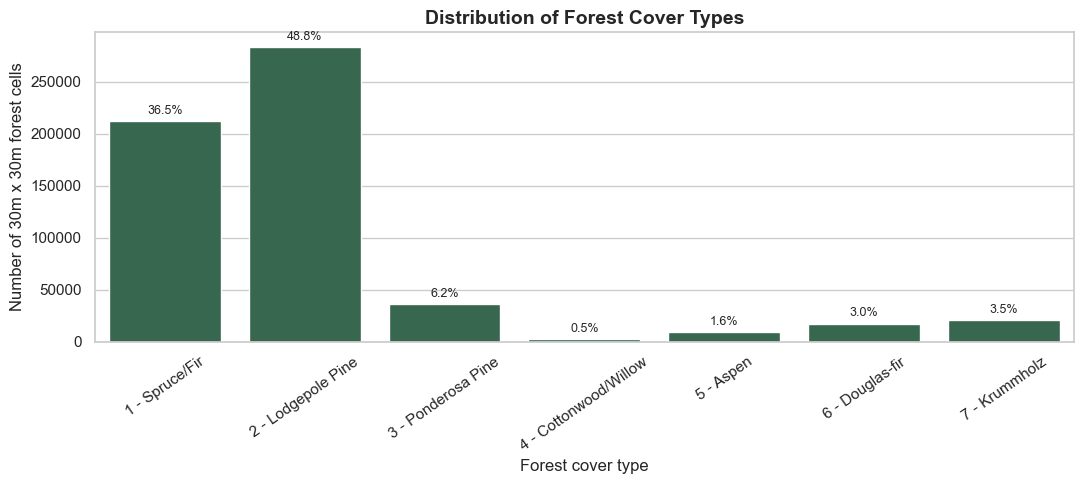

In [26]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=cover_table, x="cover_type", y="count", color="#2f6f4e", ax=ax)
ax.set_title("Distribution of Forest Cover Types", fontsize=14, weight="bold")
ax.set_xlabel("Forest cover type")
ax.set_ylabel("Number of 30m x 30m forest cells")
ax.tick_params(axis="x", rotation=35)
for container in ax.containers:
    ax.bar_label(container, labels=[f"{p:.1f}%" for p in cover_table["percent"]], padding=3, fontsize=9)
plt.tight_layout()
plt.show()

#### Interpretation

The target is strongly imbalanced. Lodgepole Pine and Spruce/Fir are the dominant classes, at about 48.8% and 36.5% of the rows. Cottonwood/Willow is very rare, at about 0.47%. A model can look good on accuracy while still doing poorly on rare cover types, so later comparisons should include per-class metrics.

## Continuous Cartographic Features

In [27]:
continuous_summary = X[continuous_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
continuous_summary.index = [feature_labels.get(c, c) for c in continuous_summary.index]
continuous_summary.round(2)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Elevation (m),581012.0,2959.37,279.98,1859.0,2122.0,2406.0,2809.0,2996.0,3163.0,3336.0,3438.0,3858.0
Aspect (degrees azimuth),581012.0,155.66,111.91,0.0,1.0,12.0,58.0,127.0,260.0,344.0,356.0,360.0
Slope (degrees),581012.0,14.10,7.49,0.0,2.0,4.0,9.0,13.0,18.0,28.0,35.0,66.0
Horizontal distance to hydrology (m),581012.0,269.43,212.55,0.0,0.0,30.0,108.0,218.0,384.0,684.0,937.0,1397.0
Vertical distance to hydrology (m),581012.0,46.42,58.30,-173.0,-42.0,-8.0,7.0,30.0,69.0,165.0,251.0,601.0
Horizontal distance to roadways (m),581012.0,2350.15,1559.25,0.0,150.0,379.0,1106.0,1997.0,3328.0,5483.0,6112.0,7117.0
Hillshade at 9am (0-255),581012.0,212.15,26.77,0.0,127.0,160.0,198.0,218.0,231.0,246.0,252.0,254.0
Hillshade at noon (0-255),581012.0,223.32,19.77,0.0,162.0,186.0,213.0,226.0,237.0,250.0,254.0,254.0
Hillshade at 3pm (0-255),581012.0,142.53,38.27,0.0,41.0,78.0,119.0,143.0,168.0,204.0,226.0,254.0
Horizontal distance to fire points (m),581012.0,1980.29,1324.20,0.0,182.0,418.0,1024.0,1710.0,2550.0,4944.0,6262.0,7173.0


#### Interpretation

The continuous features use very different units and ranges. Elevation is measured in meters, hillshade is bounded between 0 and 255, and aspect is circular in degrees. Tree models can usually handle these raw scales, but distance-based models need a careful metric, and linear online models need scale-invariant updates or normalization.

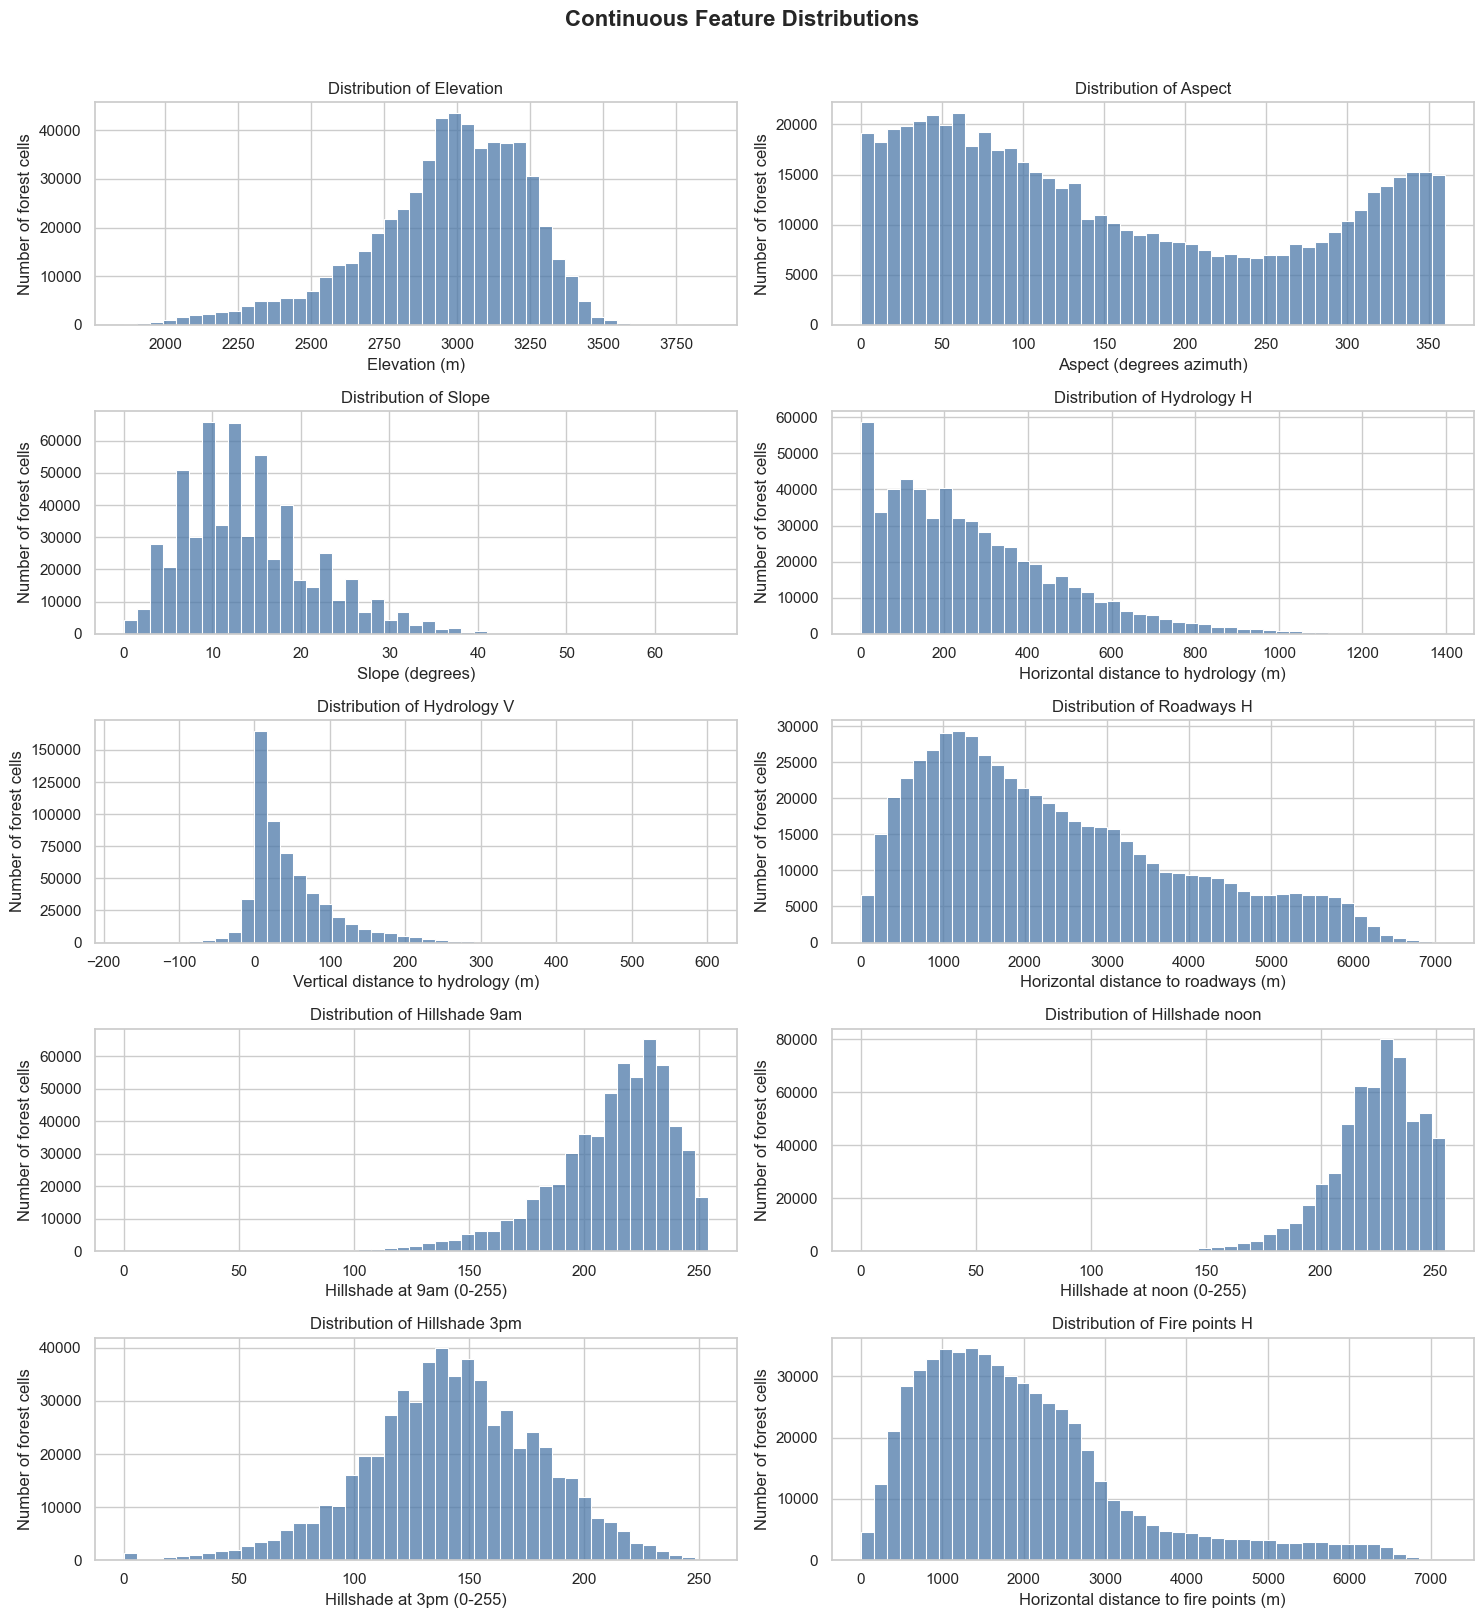

In [28]:
fig, axes = plt.subplots(5, 2, figsize=(15, 16))
axes = axes.ravel()
for ax, col in zip(axes, continuous_cols):
    sns.histplot(X[col], bins=45, color="#4c78a8", edgecolor="white", ax=ax)
    ax.set_title(f"Distribution of {short_feature_labels[col]}")
    ax.set_xlabel(feature_labels[col])
    ax.set_ylabel("Number of forest cells")
for ax in axes[len(continuous_cols):]:
    ax.axis("off")
fig.suptitle("Continuous Feature Distributions", fontsize=16, weight="bold", y=1.01)
plt.tight_layout()
plt.show()

#### Interpretation

Most continuous features are not normally distributed. Several distance variables have long right tails, which is expected for geography. These long tails are one reason why a Log-Euclidean transform can be useful for instance-based methods: it reduces the dominance of very large raw distances.

#### Continuous Features by Cover Type

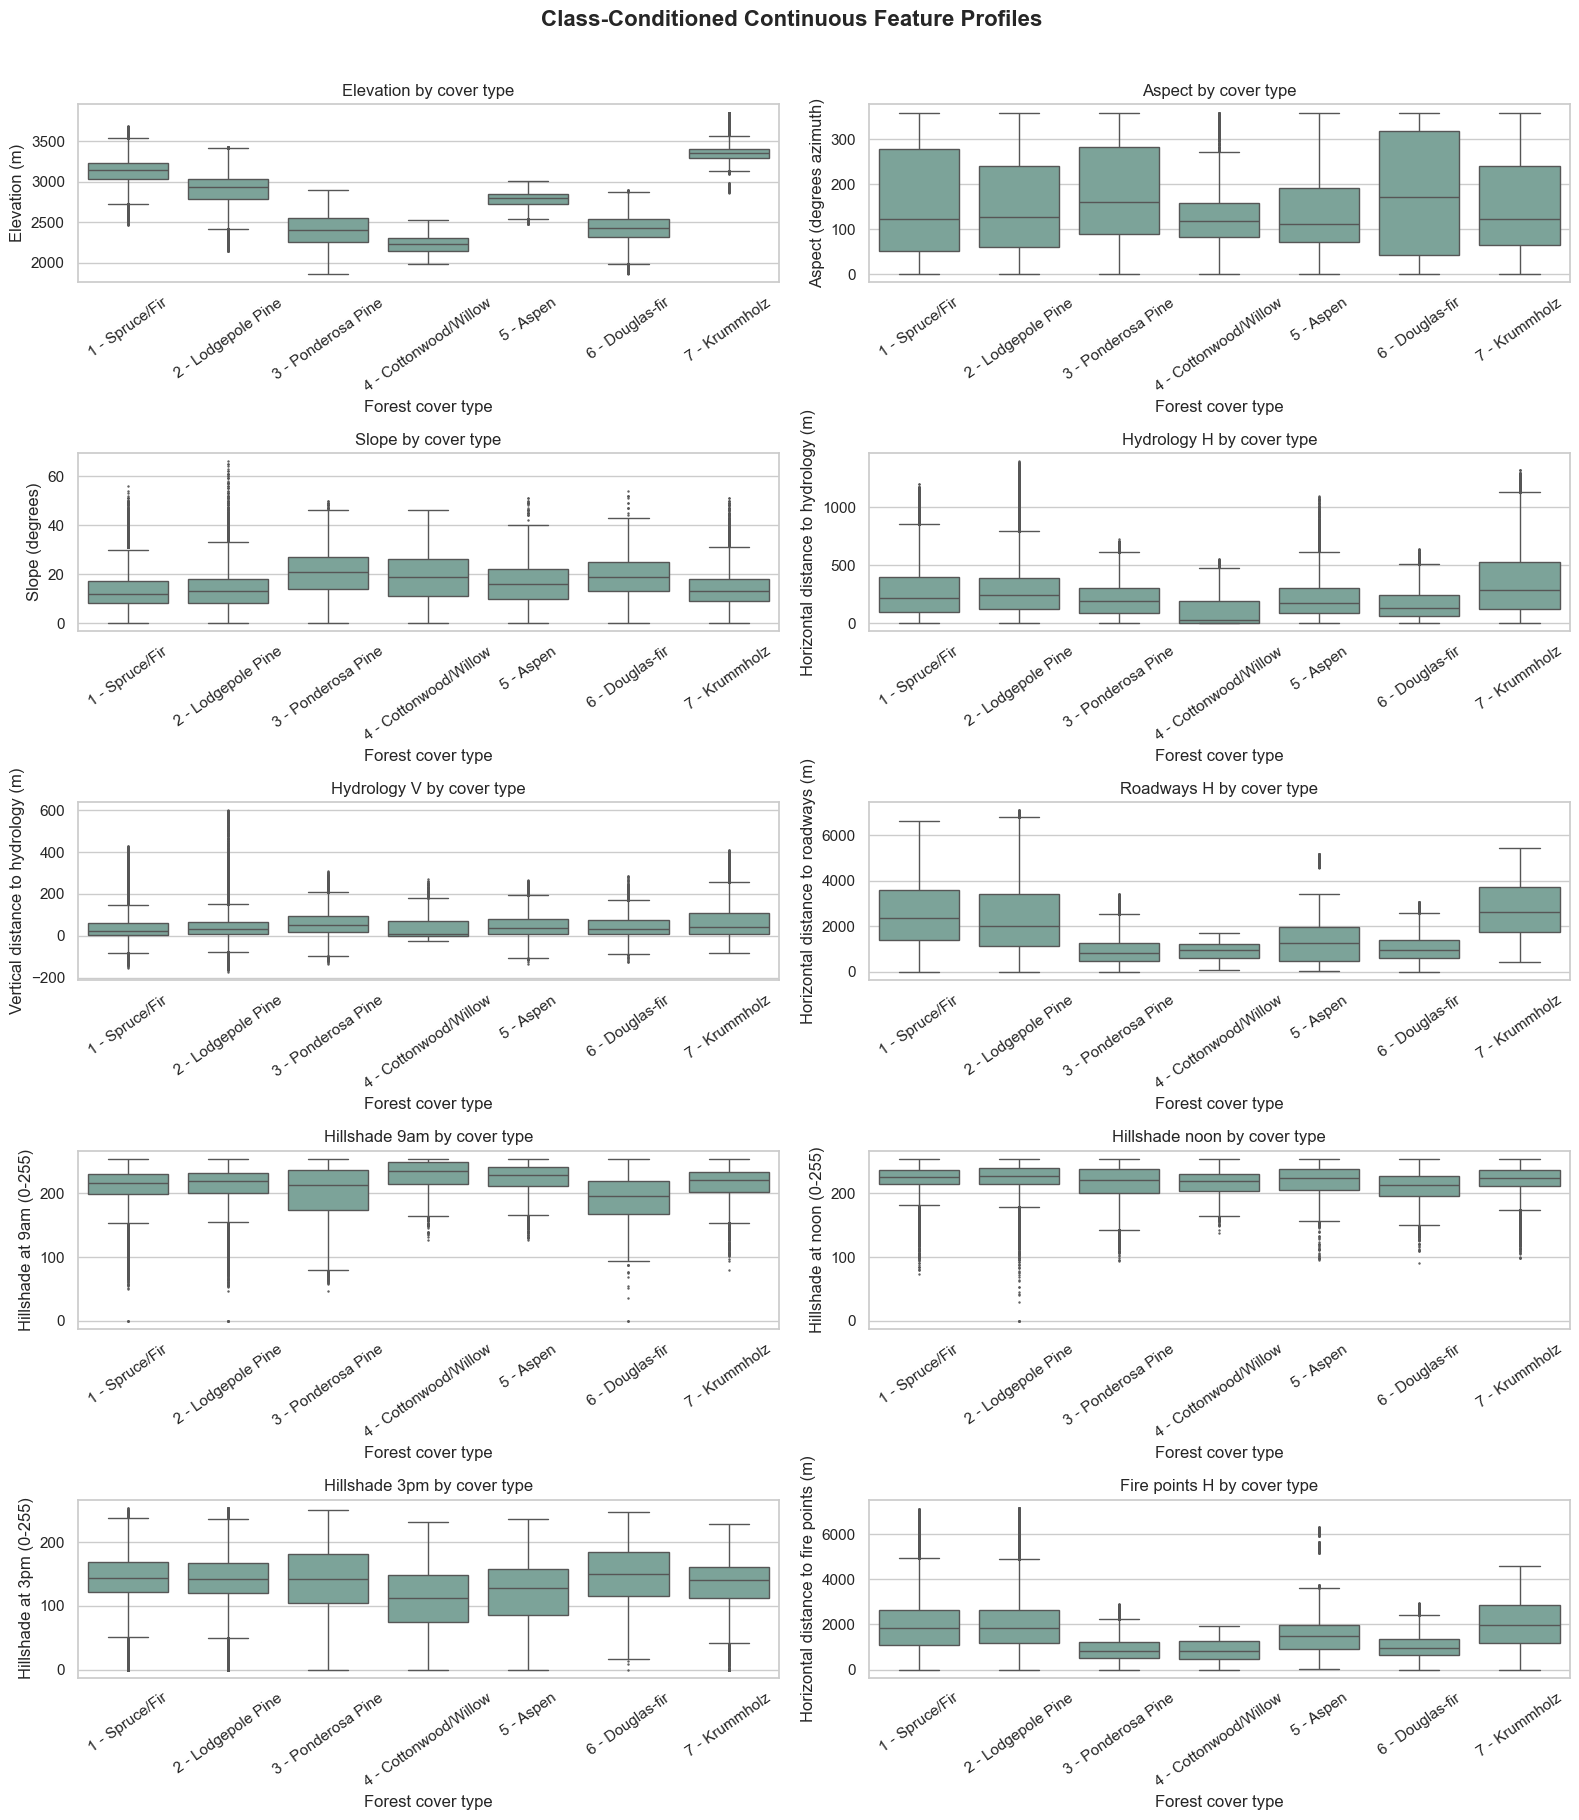

In [29]:
fig, axes = plt.subplots(5, 2, figsize=(16, 18))
axes = axes.ravel()
for ax, col in zip(axes, continuous_cols):
    sns.boxplot(
        data=df_plot,
        x="Cover_Label",
        y=col,
        order=cover_order,
        color="#75a99c",
        fliersize=0.7,
        ax=ax,
    )
    ax.set_title(f"{short_feature_labels[col]} by cover type")
    ax.set_xlabel("Forest cover type")
    ax.set_ylabel(feature_labels[col])
    ax.tick_params(axis="x", rotation=35)
for ax in axes[len(continuous_cols):]:
    ax.axis("off")
fig.suptitle("Class-Conditioned Continuous Feature Profiles", fontsize=16, weight="bold", y=1.01)
plt.tight_layout()
plt.show()

#### Interpretation

Elevation gives strong class separation. Krummholz has the highest median elevation, while Cottonwood/Willow has the lowest. Other features also help, but the boxplots overlap, so no single continuous feature fully solves the classification problem.

#### Class Profiles from Continuous Feature Medians

,Elevation (m),Aspect (degrees azimuth),Slope (degrees),Horizontal distance to hydrology (m),Vertical distance to hydrology (m),Horizontal distance to roadways (m),Hillshade at 9am (0-255),Hillshade at noon (0-255),Hillshade at 3pm (0-255),Horizontal distance to fire points (m)
1 - Spruce/Fir,3146.0,122.0,12.0,218.0,24.0,2389.0,216.0,226.0,144.0,1825.0
2 - Lodgepole Pine,2935.0,127.0,13.0,240.0,30.0,2039.0,219.0,227.0,142.0,1846.0
3 - Ponderosa Pine,2404.0,160.0,21.0,190.0,50.0,853.0,213.0,221.0,142.0,824.0
4 - Cottonwood/Willow,2231.0,119.0,19.0,30.0,6.0,949.0,235.0,220.0,113.0,806.0
5 - Aspen,2796.0,111.0,16.0,175.0,35.0,1282.0,228.0,224.0,128.0,1471.0
6 - Douglas-fir,2428.0,173.0,19.0,134.0,34.0,966.0,196.0,213.0,150.0,942.0
7 - Krummholz,3363.0,123.0,13.0,283.0,43.0,2654.0,221.0,224.0,140.0,1969.0


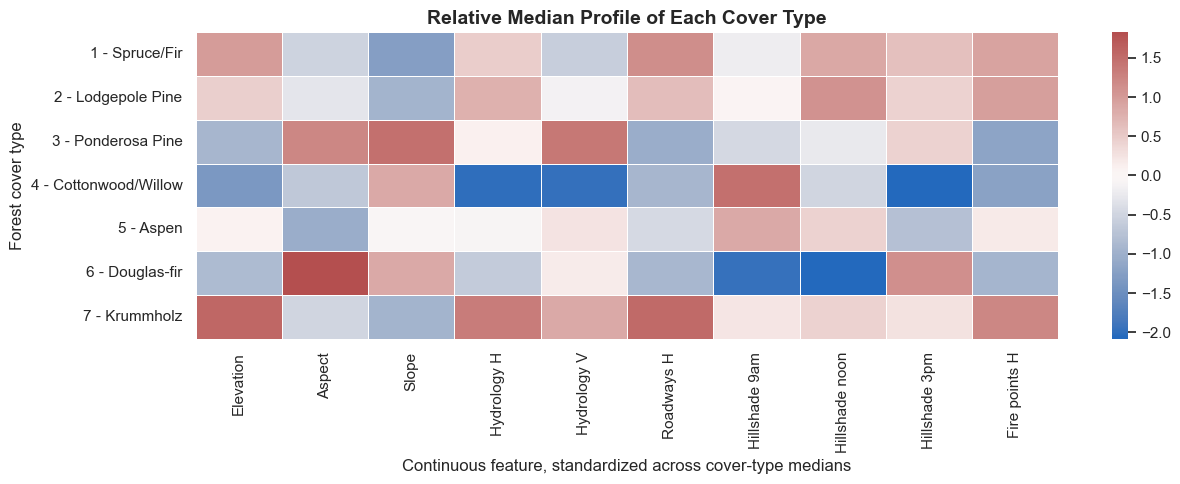

In [30]:
class_medians = df.groupby("Cover_Type")[continuous_cols].median()
class_medians.index = [cover_label(i) for i in class_medians.index]
display(class_medians.rename(columns=feature_labels).round(1))

z_profile = pd.DataFrame(
    StandardScaler().fit_transform(class_medians),
    index=class_medians.index,
    columns=[short_feature_labels[c] for c in continuous_cols],
)

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(z_profile, cmap="vlag", center=0, linewidths=0.5, ax=ax)
ax.set_title("Relative Median Profile of Each Cover Type", fontsize=14, weight="bold")
ax.set_xlabel("Continuous feature, standardized across cover-type medians")
ax.set_ylabel("Forest cover type")
plt.tight_layout()
plt.show()

#### Interpretation

The median profiles show that each cover type has a different ecological signature. For example, high-elevation classes and low-elevation classes are clearly separated. These profiles support using feature selection and feature-cost pruning, because not every feature contributes the same amount of signal.

## Outlier and Range Checks

In [31]:
outlier_rows = []
for col in continuous_cols:
    q1, q3 = X[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = ((X[col] < lower) | (X[col] > upper)).sum()
    outlier_rows.append(
        {
            "feature": feature_labels[col],
            "lower_iqr_fence": round(lower, 2),
            "upper_iqr_fence": round(upper, 2),
            "outlier_rows": int(outliers),
            "outlier_percent": round(outliers / len(X) * 100, 2),
        }
    )

outlier_table = pd.DataFrame(outlier_rows).sort_values("outlier_percent", ascending=False)
outlier_table

,feature,lower_iqr_fence,upper_iqr_fence,outlier_rows,outlier_percent
4,Vertical distance to hydrology (m),-86.0,162.0,31463,5.42
9,Horizontal distance to fire points (m),-1265.0,4839.0,31157,5.36
6,Hillshade at 9am (0-255),148.5,280.5,17433,3.00
7,Hillshade at noon (0-255),177.0,273.0,15672,2.70
0,Elevation (m),2278.0,3694.0,15569,2.68
2,Slope (degrees),-4.5,31.5,15316,2.64
3,Horizontal distance to hydrology (m),-306.0,798.0,14557,2.51
8,Hillshade at 3pm (0-255),45.5,241.5,7832,1.35
5,Horizontal distance to roadways (m),-2227.0,6661.0,669,0.12
1,Aspect (degrees azimuth),-245.0,563.0,0,0.00


#### Interpretation

The IQR rule flags outliers in several physical features, especially vertical hydrology distance and distance to fire points. These values are not automatically errors. In terrain data, extreme distances and elevation values can be real, so removing them blindly could remove useful ecological information.

In [32]:
hydrology_sign = pd.DataFrame(
    {
        "vertical_distance_sign": ["below water feature", "same elevation", "above water feature"],
        "rows": [
            int((X["Vertical_Distance_To_Hydrology"] < 0).sum()),
            int((X["Vertical_Distance_To_Hydrology"] == 0).sum()),
            int((X["Vertical_Distance_To_Hydrology"] > 0).sum()),
        ],
    }
)
hydrology_sign["percent"] = (hydrology_sign["rows"] / len(X) * 100).round(2)
hydrology_sign

,vertical_distance_sign,rows,percent
0,below water feature,55143,9.49
1,same elevation,38665,6.65
2,above water feature,487204,83.85


#### Interpretation

Vertical distance to hydrology can be negative, zero, or positive. Negative values mean the forest cell is below the nearby water feature. This is meaningful terrain information, so the project keeps the sign for models that can use it and applies a positive offset only when a log distance metric needs it.

The vertical hydrology distance can be negative. That is meaningful terrain information, not automatically bad data. Distance-based models in this project use a positive offset before applying Log-Euclidean distances rather than discarding the sign globally.

## Relationships Among Physical Variables

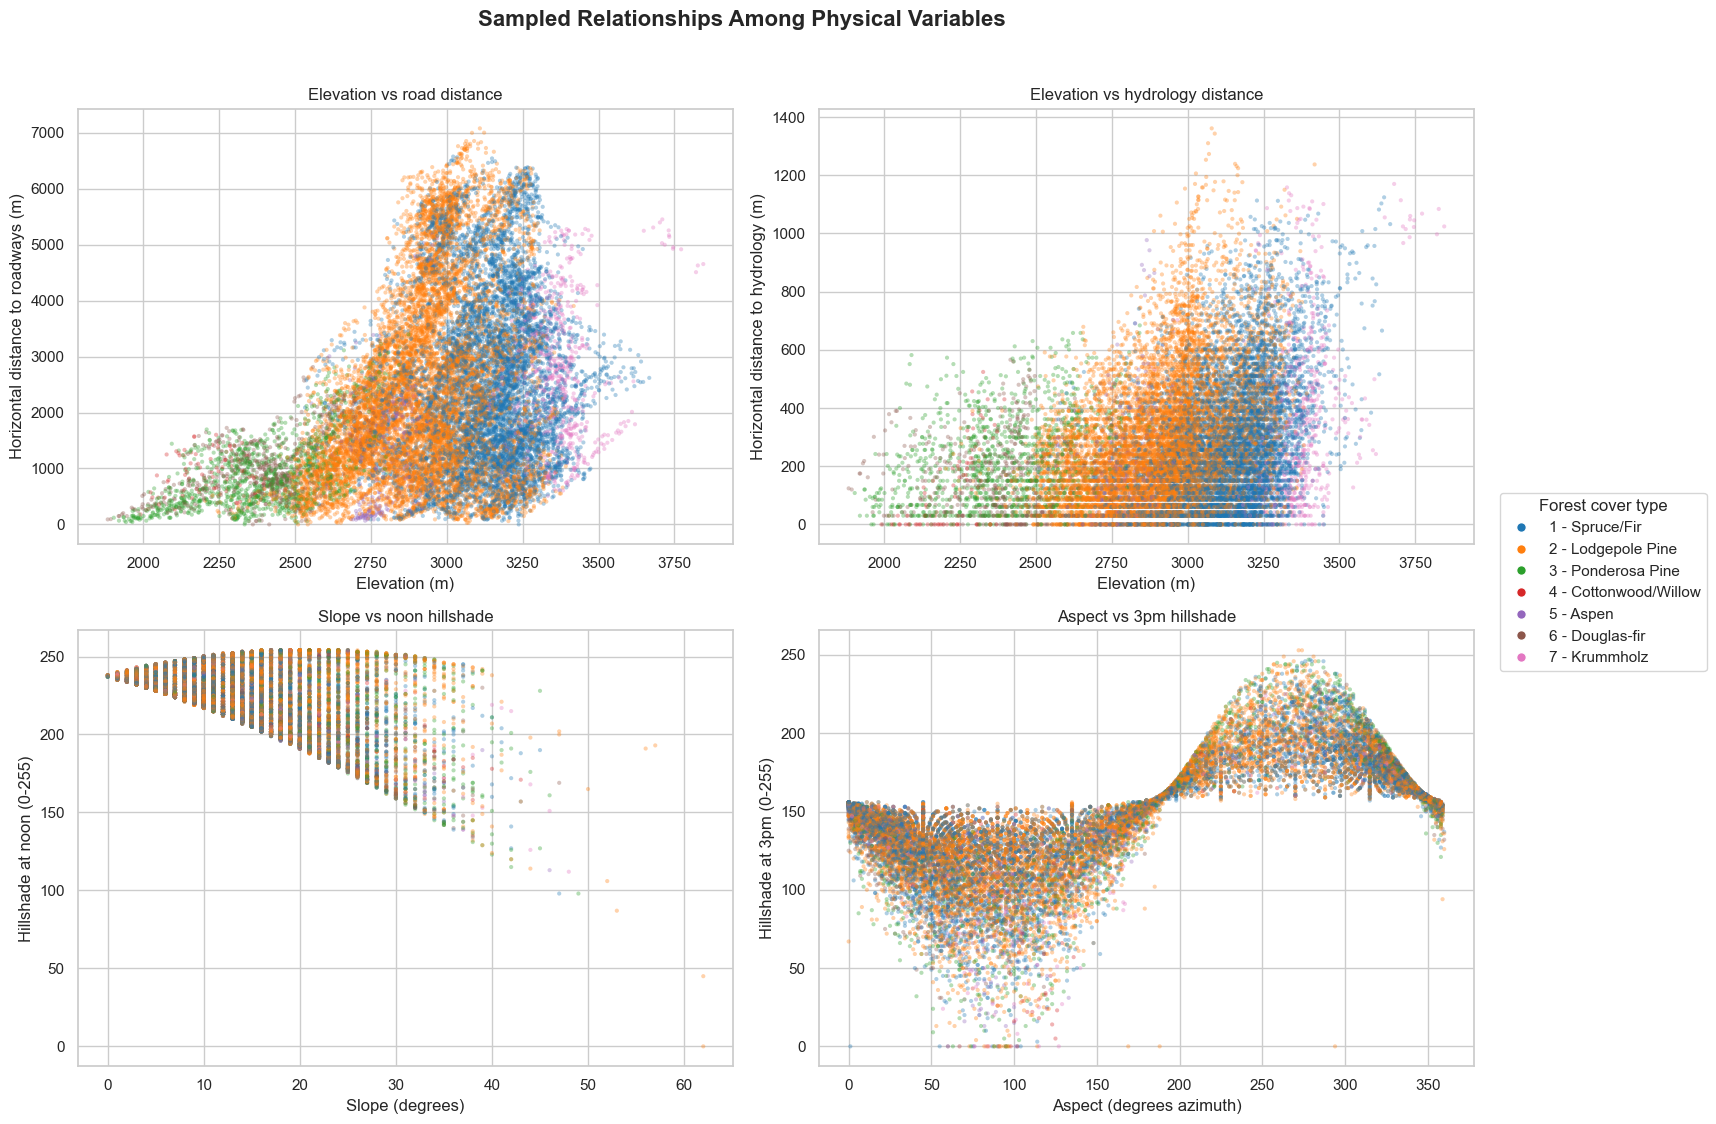

In [33]:
from matplotlib.lines import Line2D

sample_plot = df_plot.sample(n=min(20000, len(df_plot)), random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
scatter_specs = [
    ("Elevation", "Horizontal_Distance_To_Roadways", "Elevation vs road distance"),
    ("Elevation", "Horizontal_Distance_To_Hydrology", "Elevation vs hydrology distance"),
    ("Slope", "Hillshade_Noon", "Slope vs noon hillshade"),
    ("Aspect", "Hillshade_3pm", "Aspect vs 3pm hillshade"),
]

for ax, (x_col, y_col, title) in zip(axes.ravel(), scatter_specs):
    sns.scatterplot(
        data=sample_plot,
        x=x_col,
        y=y_col,
        hue="Cover_Label",
        palette=palette,
        s=9,
        alpha=0.35,
        linewidth=0,
        ax=ax,
        legend=False,
    )
    ax.set_title(title)
    ax.set_xlabel(feature_labels[x_col])
    ax.set_ylabel(feature_labels[y_col])

legend_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=palette[label], label=label, markersize=7)
    for label in cover_order
]
fig.legend(handles=legend_handles, title="Forest cover type", loc="center left", bbox_to_anchor=(1.0, 0.5))
fig.suptitle("Sampled Relationships Among Physical Variables", fontsize=16, weight="bold", y=1.02)
plt.tight_layout()
plt.show()

#### Interpretation

The scatterplots show real structure, but also heavy overlap between classes. This suggests that a simple linear boundary will not capture all class differences. Nonlinear models such as forests, OPF, k-NN, and stream trees are reasonable baselines for this dataset.

## Correlation Analysis

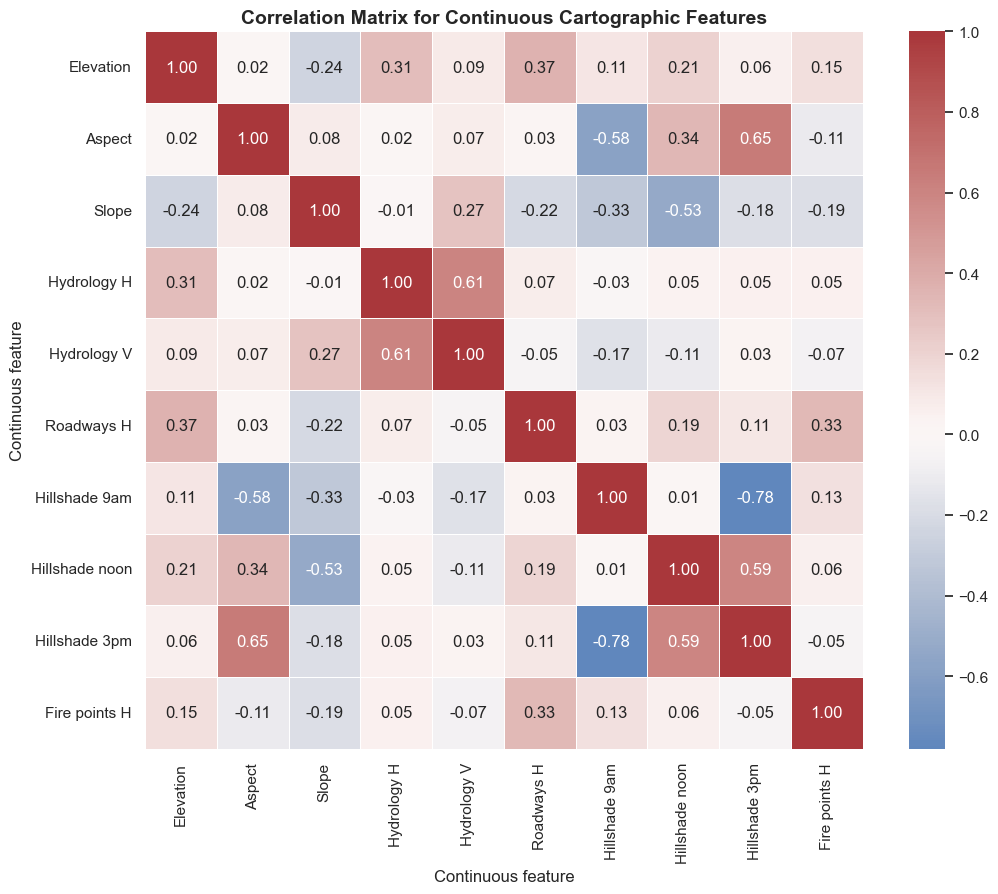

In [34]:
corr = X[continuous_cols].corr()
corr_display = corr.rename(index=short_feature_labels, columns=short_feature_labels)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_display, cmap="vlag", center=0, square=True, linewidths=0.4, annot=True, fmt=".2f", ax=ax)
ax.set_title("Correlation Matrix for Continuous Cartographic Features", fontsize=14, weight="bold")
ax.set_xlabel("Continuous feature")
ax.set_ylabel("Continuous feature")
plt.tight_layout()
plt.show()

#### Interpretation

Some continuous features are strongly related. Hillshade at 9am and 3pm are negatively correlated, and aspect is linked to hillshade because sun direction changes the amount of light on a slope. Correlation does not make a feature useless, but it matters for L1 models and feature-budget pruning because they may prefer one feature from a correlated group.

In [35]:
corr_pairs = []
for i, left in enumerate(continuous_cols):
    for right in continuous_cols[i + 1:]:
        corr_pairs.append(
            {
                "feature_1": feature_labels[left],
                "feature_2": feature_labels[right],
                "correlation": corr.loc[left, right],
                "absolute_correlation": abs(corr.loc[left, right]),
            }
        )

pd.DataFrame(corr_pairs).sort_values("absolute_correlation", ascending=False).head(12).round(3)

,feature_1,feature_2,correlation,absolute_correlation
40,Hillshade at 9am (0-255),Hillshade at 3pm (0-255),-0.780,0.780
15,Aspect (degrees azimuth),Hillshade at 3pm (0-255),0.647,0.647
24,Horizontal distance to hydrology (m),Vertical distance to hydrology (m),0.606,0.606
42,Hillshade at noon (0-255),Hillshade at 3pm (0-255),0.594,0.594
13,Aspect (degrees azimuth),Hillshade at 9am (0-255),-0.579,0.579
21,Slope (degrees),Hillshade at noon (0-255),-0.527,0.527
4,Elevation (m),Horizontal distance to roadways (m),0.366,0.366
14,Aspect (degrees azimuth),Hillshade at noon (0-255),0.336,0.336
38,Horizontal distance to roadways (m),Horizontal distance to fire points (m),0.332,0.332
20,Slope (degrees),Hillshade at 9am (0-255),-0.327,0.327


#### Interpretation

The strongest correlations mostly come from hillshade, aspect, slope, and hydrology-distance relationships. This means feature interactions are present in the raw data. Random forests can use these interactions naturally, while linear models may need more careful feature selection.

## Wilderness and Soil Indicator Analysis

In [36]:
wilderness_counts = X[wilderness_cols].sum().sort_values(ascending=False)
soil_counts = X[soil_cols].sum().sort_values(ascending=False)

display(wilderness_counts.rename("rows").to_frame())
display(soil_counts.head(15).rename("rows").to_frame())
rare_binary.rename("rows").to_frame()

,rows
Wilderness_Area1,260796
Wilderness_Area3,253364
Wilderness_Area4,36968
Wilderness_Area2,29884


,rows
Soil_Type29,115247
Soil_Type23,57752
Soil_Type32,52519
Soil_Type33,45154
Soil_Type22,33373
Soil_Type10,32634
Soil_Type30,30170
Soil_Type12,29971
Soil_Type31,25666
Soil_Type24,21278


,rows
Soil_Type15,3
Soil_Type7,105
Soil_Type36,119
Soil_Type8,179
Soil_Type37,298
Soil_Type25,474
Soil_Type14,599
Soil_Type21,838
Soil_Type28,946
Soil_Type27,1086


#### Interpretation

The wilderness areas are not equally represented. Wilderness_Area1 and Wilderness_Area3 contain most rows, while Wilderness_Area2 and Wilderness_Area4 are smaller. Soil types are even more uneven: Soil_Type29 is very common, while Soil_Type15 appears only a few times. Rare indicators should be interpreted carefully because their estimates can be unstable.

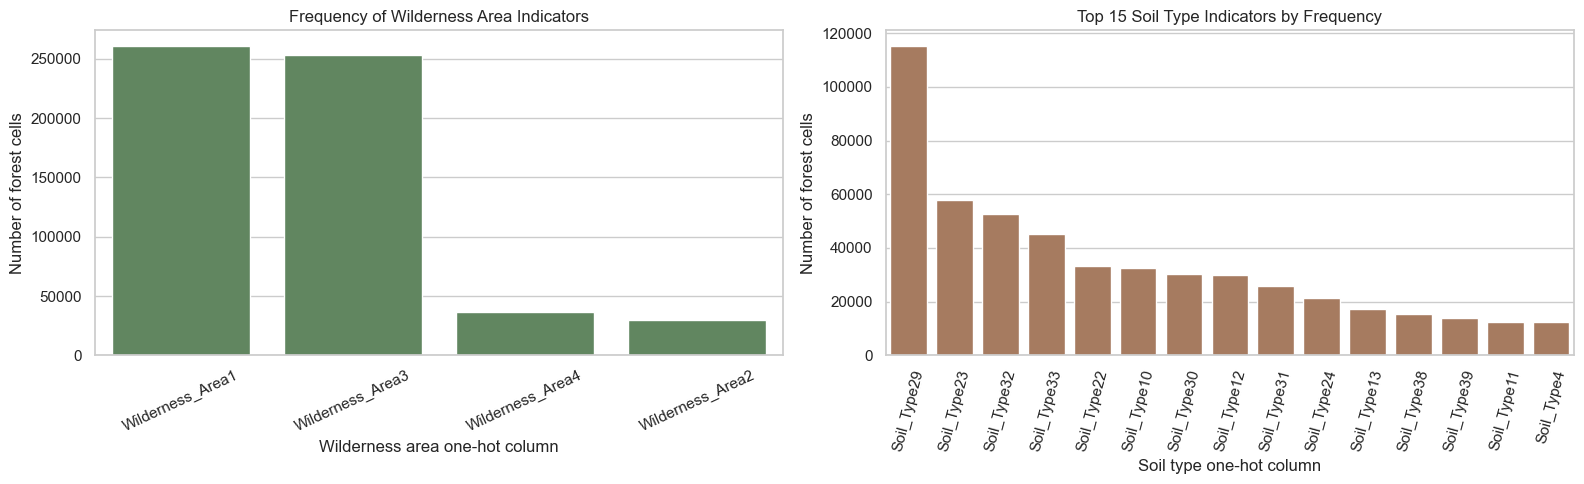

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(x=wilderness_counts.index, y=wilderness_counts.values, color="#5b8c5a", ax=axes[0])
axes[0].set_title("Frequency of Wilderness Area Indicators")
axes[0].set_xlabel("Wilderness area one-hot column")
axes[0].set_ylabel("Number of forest cells")
axes[0].tick_params(axis="x", rotation=25)

top_soils = soil_counts.head(15)
sns.barplot(x=top_soils.index, y=top_soils.values, color="#b27954", ax=axes[1])
axes[1].set_title("Top 15 Soil Type Indicators by Frequency")
axes[1].set_xlabel("Soil type one-hot column")
axes[1].set_ylabel("Number of forest cells")
axes[1].tick_params(axis="x", rotation=75)

plt.tight_layout()
plt.show()

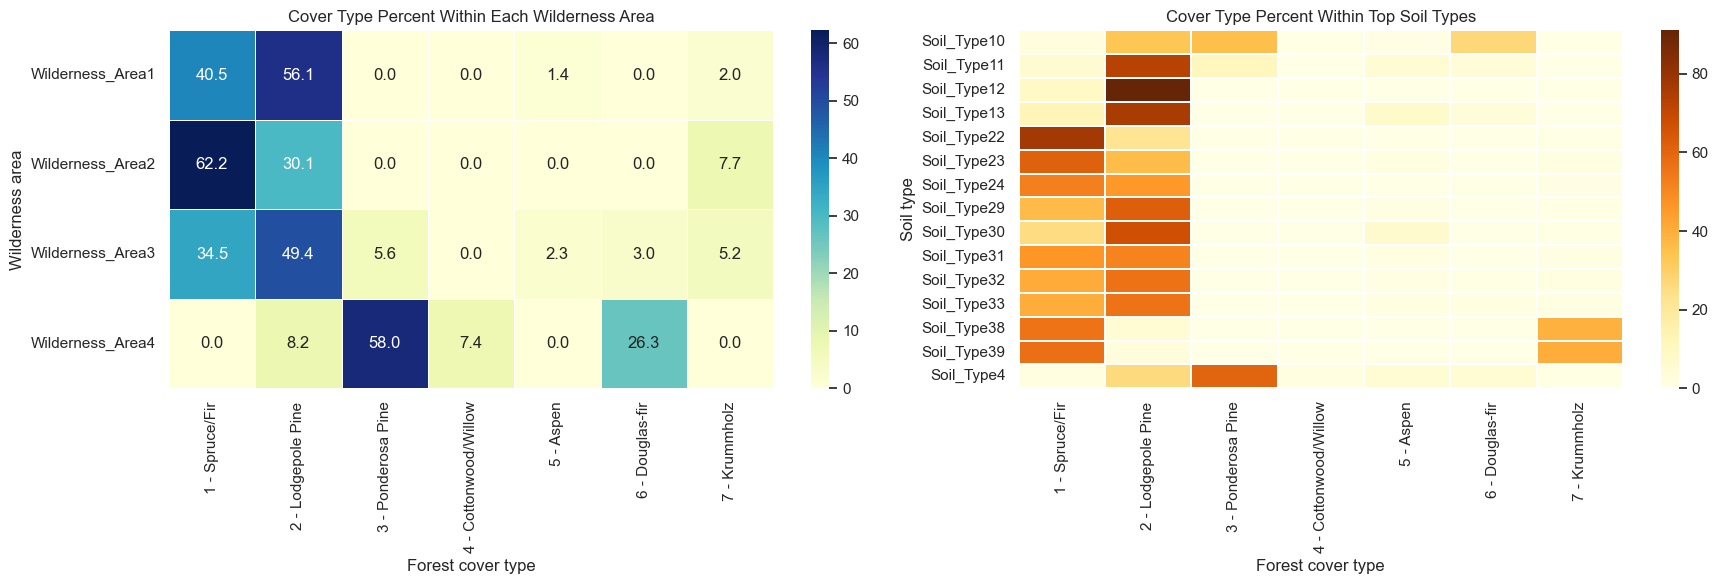

In [38]:
wilderness_active = X[wilderness_cols].idxmax(axis=1)
soil_active = X[soil_cols].idxmax(axis=1)

wilderness_cover = pd.crosstab(wilderness_active, df_plot["Cover_Label"], normalize="index") * 100
top_soil_names = soil_counts.head(15).index
soil_cover = pd.crosstab(soil_active[soil_active.isin(top_soil_names)], df_plot.loc[soil_active.isin(top_soil_names), "Cover_Label"], normalize="index") * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.heatmap(wilderness_cover, cmap="YlGnBu", annot=True, fmt=".1f", linewidths=0.4, ax=axes[0])
axes[0].set_title("Cover Type Percent Within Each Wilderness Area")
axes[0].set_xlabel("Forest cover type")
axes[0].set_ylabel("Wilderness area")

sns.heatmap(soil_cover, cmap="YlOrBr", annot=False, linewidths=0.2, ax=axes[1])
axes[1].set_title("Cover Type Percent Within Top Soil Types")
axes[1].set_xlabel("Forest cover type")
axes[1].set_ylabel("Soil type")

plt.tight_layout()
plt.show()

#### Interpretation

The heatmaps show that wilderness area and soil type are strongly connected to cover type. Some areas and soils are dominated by a small set of covers. These categorical indicators should be useful for trees and forests, and they are also good candidates for cost-aware feature selection.

## Feature Relevance Snapshot

Mutual information gives a quick, model-agnostic view of which features are most associated with the cover label. It is not a final feature selection result, but it helps guide the sample tuning notebook.

In [39]:
mi_sample = df.sample(n=min(50000, len(df)), random_state=42)
mi_X = mi_sample[X.columns]
mi_y = mi_sample["Cover_Type"]
discrete_mask = np.array([col in binary_cols for col in X.columns])
mi_scores = pd.Series(
    mutual_info_classif(mi_X, mi_y, discrete_features=discrete_mask, random_state=42),
    index=X.columns,
).sort_values(ascending=False)

mi_display = mi_scores.head(25).rename_axis("feature").reset_index(name="mutual_information")
mi_display["feature_label"] = mi_display["feature"].map(lambda c: feature_labels.get(c, c))
mi_display[["feature_label", "mutual_information"]].round(4)

,feature_label,mutual_information
0,Elevation (m),0.4531
1,Wilderness_Area4,0.1430
2,Horizontal distance to roadways (m),0.0873
3,Horizontal distance to fire points (m),0.0677
4,Wilderness_Area1,0.0658
5,Soil_Type10,0.0601
6,Slope (degrees),0.0361
7,Soil_Type38,0.0298
8,Soil_Type29,0.0291
9,Hillshade at 9am (0-255),0.0288


#### Interpretation

Mutual information ranks Elevation as the strongest single feature in the sample. Wilderness_Area4, road distance, fire-point distance, and several soil types also carry useful signal. This supports the feature subsets used later, such as top-20 and top-35 mutual-information features.

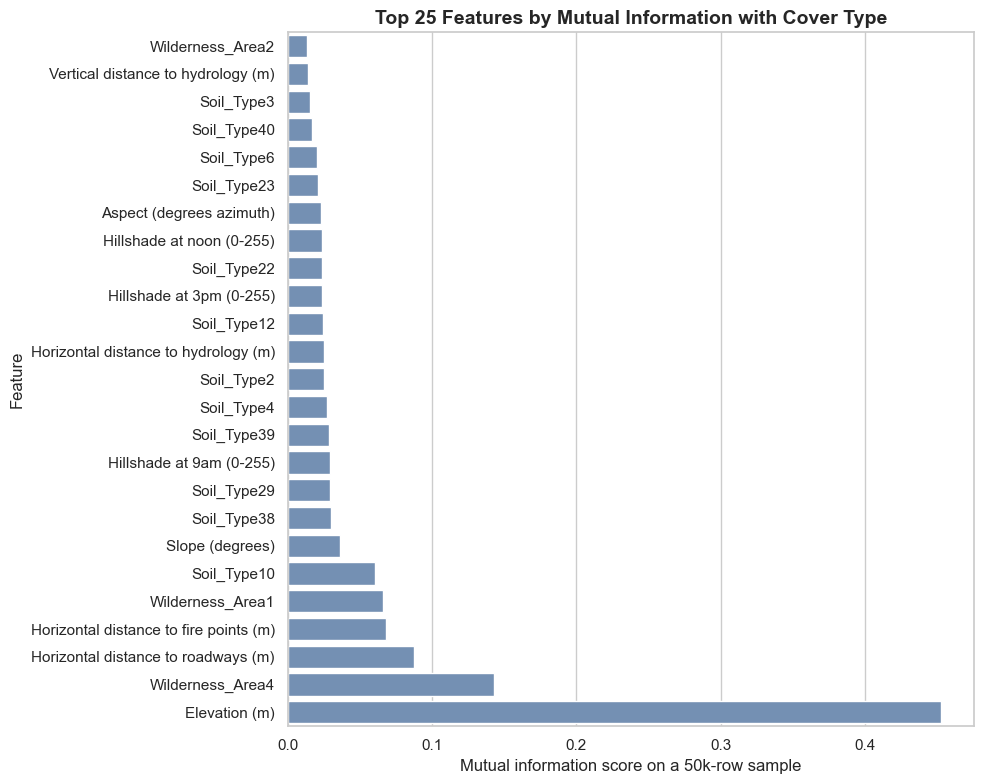

In [40]:
fig, ax = plt.subplots(figsize=(10, 8))
plot_df = mi_display.sort_values("mutual_information", ascending=True)
sns.barplot(data=plot_df, y="feature_label", x="mutual_information", color="#6a8fbd", ax=ax)
ax.set_title("Top 25 Features by Mutual Information with Cover Type", fontsize=14, weight="bold")
ax.set_xlabel("Mutual information score on a 50k-row sample")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

#### Interpretation

The feature ranking agrees with the visual analysis: elevation is very important, but it is not the only useful signal. Distance, wilderness, and soil features add information. Mutual information checks one feature at a time, so it should guide feature selection, not replace model validation.

## Low-Dimensional View of the Dataset

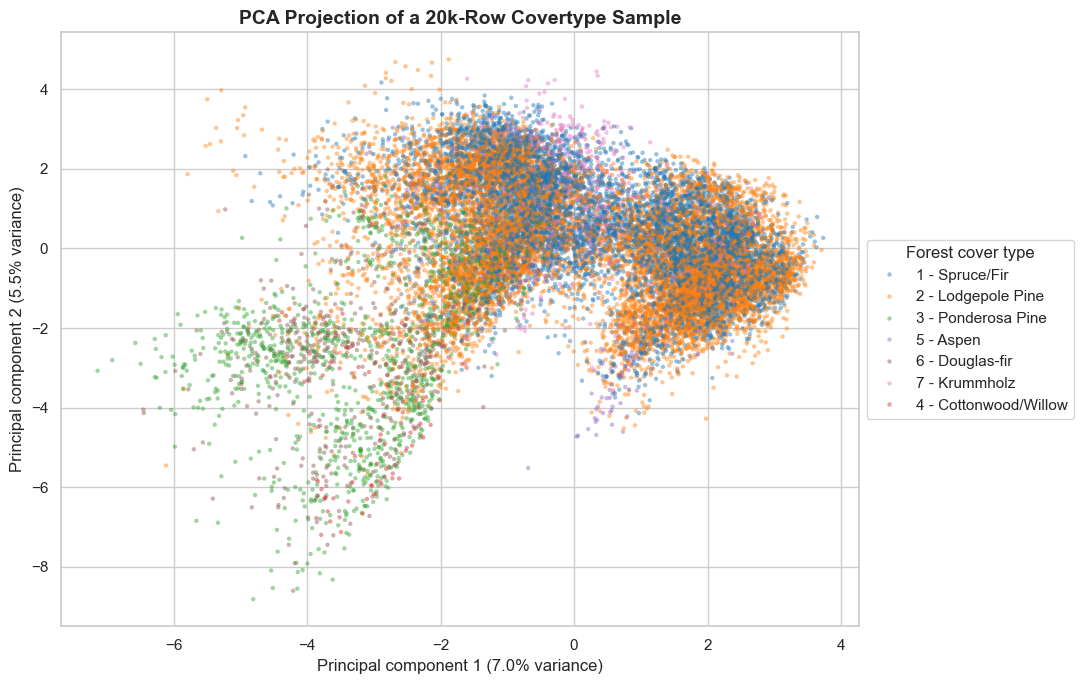

In [41]:
pca_sample = df_plot.sample(n=min(20000, len(df_plot)), random_state=42)
scaled_sample = StandardScaler().fit_transform(pca_sample[X.columns])
pca = PCA(n_components=2, random_state=42)
components = pca.fit_transform(scaled_sample)
pca_df = pd.DataFrame(
    {
        "PC1": components[:, 0],
        "PC2": components[:, 1],
        "Cover_Label": pca_sample["Cover_Label"].to_numpy(),
    }
)

fig, ax = plt.subplots(figsize=(11, 7))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cover_Label",
    palette=palette,
    s=10,
    alpha=0.45,
    linewidth=0,
    ax=ax,
)
ax.set_title("PCA Projection of a 20k-Row Covertype Sample", fontsize=14, weight="bold")
ax.set_xlabel(f"Principal component 1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")
ax.set_ylabel(f"Principal component 2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")
ax.legend(title="Forest cover type", loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

#### Interpretation

The PCA plot shows partial grouping by cover type, but the classes still overlap. This is normal for ecological tabular data. Two principal components are helpful for visualization, but they are not enough to separate all seven classes cleanly.

## Log-Euclidean Distance Readiness

The OPF and k-NN baselines use Log-Euclidean distances. Because Covertype contains zeros and one signed distance feature, the transformer learns the smallest positive coordinate offset before taking logarithms.

In [42]:
log_metric = LogEuclideanTransformer().fit(X)
offsets = pd.Series(log_metric.offset_, index=X.columns, name="positive_offset")
offset_table = offsets[offsets > 0].sort_values(ascending=False).rename_axis("feature").reset_index()
offset_table["feature_label"] = offset_table["feature"].map(lambda c: feature_labels.get(c, c))
offset_table[["feature_label", "positive_offset"]].head(20)

,feature_label,positive_offset
0,Vertical distance to hydrology (m),174.0
1,Aspect (degrees azimuth),1.0
2,Slope (degrees),1.0
3,Horizontal distance to hydrology (m),1.0
4,Horizontal distance to roadways (m),1.0
5,Hillshade at 9am (0-255),1.0
6,Hillshade at noon (0-255),1.0
7,Hillshade at 3pm (0-255),1.0
8,Horizontal distance to fire points (m),1.0
9,Wilderness_Area1,1.0


#### Interpretation

Several features need a positive offset before the log transform because they can be zero or negative. This does not change the raw dataset globally. It only makes the Log-Euclidean distance safe for OPF and k-NN style models.

In [43]:
distance_examples = []
for i, j in [(0, 1), (0, 10), (100, 500), (1000, 2000), (10000, 50000)]:
    distance_examples.append(
        {
            "row_i": i,
            "row_j": j,
            "cover_i": cover_label(y.iloc[i]),
            "cover_j": cover_label(y.iloc[j]),
            "same_cover": bool(y.iloc[i] == y.iloc[j]),
            "log_euclidean_distance": round(log_metric.distance(X.iloc[i], X.iloc[j]), 4),
        }
    )

pd.DataFrame(distance_examples)

,row_i,row_j,cover_i,cover_j,same_cover,log_euclidean_distance
0,0,1,5 - Aspen,5 - Aspen,True,0.4505
1,0,10,5 - Aspen,5 - Aspen,True,1.7858
2,100,500,2 - Lodgepole Pine,2 - Lodgepole Pine,True,3.1445
3,1000,2000,2 - Lodgepole Pine,7 - Krummholz,False,1.5812
4,10000,50000,7 - Krummholz,2 - Lodgepole Pine,False,2.9423


#### Interpretation

The Log-Euclidean distance compares rows after moving features into a log domain. This makes ratio-like differences more important than raw meter differences. It is useful when very large distance values would otherwise dominate nearest-neighbor comparisons.

## Streaming Order Snapshot

In [44]:
window = 50_000
stream_windows = pd.DataFrame({"row": np.arange(len(y)), "Cover_Type": y.to_numpy()})
stream_windows["Cover_Label"] = stream_windows["Cover_Type"].map(cover_label)
stream_windows["window"] = stream_windows["row"] // window
window_mix = pd.crosstab(stream_windows["window"], stream_windows["Cover_Label"], normalize="index") * 100
window_mix.head(10).round(2)

Cover_Label,1 - Spruce/Fir,2 - Lodgepole Pine,3 - Ponderosa Pine,4 - Cottonwood/Willow,5 - Aspen,6 - Douglas-fir,7 - Krummholz
window,,,,,,,
0,20.30,57.59,4.32,4.32,4.83,4.32,4.32
1,23.75,75.92,0.00,0.00,0.33,0.00,0.00
2,21.59,77.44,0.00,0.00,0.97,0.00,0.00
3,45.55,53.00,0.00,0.00,1.45,0.00,0.00
4,32.53,48.05,7.48,0.04,3.46,5.48,2.97
5,23.29,30.47,29.18,1.10,2.00,11.43,2.54
6,40.07,46.56,5.91,0.03,2.05,3.67,1.71
7,32.92,45.15,7.53,0.00,1.91,3.46,9.04
8,61.50,31.64,1.70,0.00,1.51,1.35,2.31


#### Interpretation

The class mixture changes as rows arrive in stream order. Early windows are mostly Lodgepole Pine, while later windows contain more Spruce/Fir and other classes. This supports prequential stream evaluation, because the model is not seeing a perfectly shuffled, stationary stream.

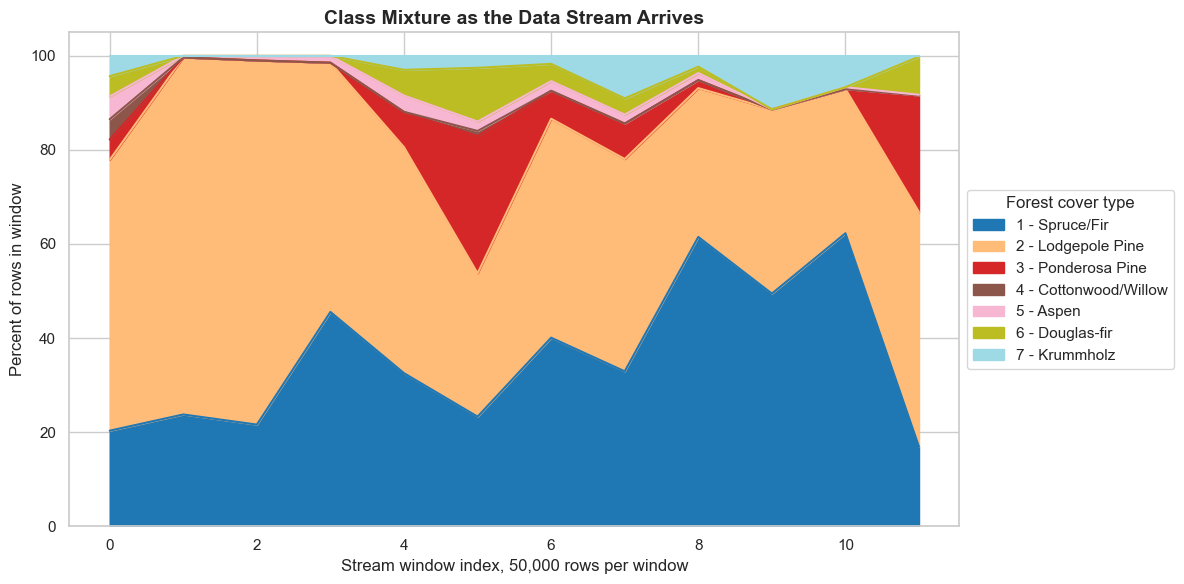

In [45]:
fig, ax = plt.subplots(figsize=(12, 6))
window_mix.plot(kind="area", stacked=True, cmap="tab20", ax=ax)
ax.set_title("Class Mixture as the Data Stream Arrives", fontsize=14, weight="bold")
ax.set_xlabel("Stream window index, 50,000 rows per window")
ax.set_ylabel("Percent of rows in window")
ax.legend(title="Forest cover type", ncol=1, loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

In [46]:
window_dominance = window_mix.idxmax(axis=1).rename("dominant_cover_type").to_frame()
window_dominance["dominant_percent"] = window_mix.max(axis=1).round(2)
window_dominance.head(15)

,dominant_cover_type,dominant_percent
window,,
0,2 - Lodgepole Pine,57.59
1,2 - Lodgepole Pine,75.92
2,2 - Lodgepole Pine,77.44
3,2 - Lodgepole Pine,53.00
4,2 - Lodgepole Pine,48.05
5,2 - Lodgepole Pine,30.47
6,2 - Lodgepole Pine,46.56
7,2 - Lodgepole Pine,45.15
8,1 - Spruce/Fir,61.50


#### Interpretation

The dominant class changes across stream windows. A streaming model should therefore be judged over time, not only by one final score. Sequential accuracy and Kappa show whether the model is adapting as the stream distribution changes.

## EDA Summary

- The full dataset contains 581,012 rows and 54 predictive columns: 10 continuous cartographic variables, 4 wilderness indicators, and 40 soil indicators.
- Cover classes are imbalanced, so model evaluation should include Kappa and per-class precision/recall in addition to accuracy.
- Elevation is visually and statistically one of the most discriminative continuous features, but soil and wilderness indicators also carry strong signal.
- Some continuous features have long tails or IQR outliers; these should be handled carefully rather than removed blindly.
- Soil and wilderness indicators are valid one-hot groups and show clear class-composition differences.
- Stream windows have changing class mixtures, supporting prequential evaluation for EFDT/Hoeffding-style models.
- Distance-based models need the positive log-domain offset used by the Log-Euclidean transformer.